In [3]:
from google.colab import drive
drive.mount('/content/drive')
!pip install segmentation-models-pytorch albumentations -q

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.2 MB/s eta 0:00:00


In [2]:
import os
import numpy as np
from PIL import Image
import torch
import torch.nn.functional as F
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

In [3]:
CLASS_MAP = {
    100: 0, 200: 1, 300: 2, 500: 3,
    550: 4, 600: 5, 700: 6, 800: 7,
    7100: 8, 10000: 9
}

def convert_mask(mask_array):
    mask_array = mask_array.astype(np.int32)
    new_mask = np.zeros_like(mask_array, dtype=np.int64)
    for original_id, new_id in CLASS_MAP.items():
        new_mask[mask_array == original_id] = new_id
    return new_mask

In [4]:
val_transform = A.Compose([
    A.Resize(512, 512),
    A.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    ToTensorV2()
])

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

model = smp.DeepLabV3Plus(
    encoder_name="resnet101",  # ✅ same as training
    encoder_weights=None,
    in_channels=3,
    classes=10,
)
model = model.to(device)

model.load_state_dict(torch.load(
    '/content/drive/MyDrive/hackathon/best_model_v2.pth'
))
model.eval()
print("Best model v2 loaded! ✅")

Using: cuda
Best model v2 loaded! ✅


In [4]:
!unzip /content/drive/MyDrive/hackathon/Offroad_Segmentation_testImages.zip -d /content/test_data

Archive:  /content/drive/MyDrive/hackathon/Offroad_Segmentation_testImages.zip
   creating: /content/test_data/Offroad_Segmentation_testImages/
   creating: /content/test_data/Offroad_Segmentation_testImages/Color_Images/
  inflating: /content/test_data/Offroad_Segmentation_testImages/Color_Images/0000060.png  
  inflating: /content/test_data/Offroad_Segmentation_testImages/Color_Images/0000061.png  
  inflating: /content/test_data/Offroad_Segmentation_testImages/Color_Images/0000062.png  
  inflating: /content/test_data/Offroad_Segmentation_testImages/Color_Images/0000063.png  
  inflating: /content/test_data/Offroad_Segmentation_testImages/Color_Images/0000064.png  
  inflating: /content/test_data/Offroad_Segmentation_testImages/Color_Images/0000065.png  
  inflating: /content/test_data/Offroad_Segmentation_testImages/Color_Images/0000066.png  
  inflating: /content/test_data/Offroad_Segmentation_testImages/Color_Images/0000067.png  
  inflating: /content/test_data/Offroad_Segmentati

In [5]:
TEST_IMAGES = '/content/test_data/Offroad_Segmentation_testImages/Color_Images'
TEST_MASKS  = '/content/test_data/Offroad_Segmentation_testImages/Segmentation'

print(f"Test images: {len(os.listdir(TEST_IMAGES))}")
print(f"Test masks : {len(os.listdir(TEST_MASKS))}")

Test images: 1002
Test masks : 1002


In [8]:
num_classes = 10
intersection = torch.zeros(num_classes)
union = torch.zeros(num_classes)

test_files = sorted(os.listdir(TEST_IMAGES))
print(f"Evaluating {len(test_files)} test images...")

img_only_transform = A.Compose([
    A.Resize(512, 512),
    A.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    ToTensorV2()
])

for i, fname in enumerate(test_files):
    img = np.array(Image.open(
        os.path.join(TEST_IMAGES, fname)
    ).convert('RGB'))

    mask = np.array(Image.open(
        os.path.join(TEST_MASKS, fname)
    ))
    mask = convert_mask(mask)
    original_h, original_w = mask.shape
    mask_tensor = torch.tensor(mask)

    transformed = img_only_transform(image=img)
    img_tensor  = transformed['image'].unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_tensor)
        pred = F.interpolate(
            output,
            size=(original_h, original_w),
            mode='bilinear',
            align_corners=False
        ).argmax(dim=1).squeeze().cpu()

    for cls in range(num_classes):
        pred_cls = (pred == cls)
        true_cls = (mask_tensor == cls)
        intersection[cls] += (pred_cls & true_cls).sum()
        union[cls] += (pred_cls | true_cls).sum()

    del img_tensor, output, pred, mask_tensor
    torch.cuda.empty_cache()

    if (i+1) % 100 == 0:
        print(f"Processed {i+1}/{len(test_files)}...")

# Final Results
CLASS_NAMES = [
    'Trees', 'Lush Bushes', 'Dry Grass', 'Dry Bushes',
    'Ground Clutter', 'Flowers', 'Logs', 'Rocks',
    'Landscape', 'Sky'
]

iou_per_class = []
for cls in range(num_classes):
    if union[cls] == 0:
        iou_per_class.append(float('nan'))
    else:
        iou_per_class.append(
            (intersection[cls] / union[cls]).item()
        )

mean_iou = np.nanmean(iou_per_class)
print(f"\n{'='*40}")
print(f"FINAL TEST Mean IoU: {mean_iou:.4f}")
print(f"{'='*40}")
print("\nPer Class IoU:")
print("-" * 30)
for name, iou in zip(CLASS_NAMES, iou_per_class):
    if np.isnan(iou):
        print(f"{name:20s}: Not present")
    else:
        bar = '█' * int(iou * 20)
        print(f"{name:20s}: {iou:.4f} {bar}")

Evaluating 1002 test images...
Processed 100/1002...
Processed 200/1002...
Processed 300/1002...
Processed 400/1002...
Processed 500/1002...
Processed 600/1002...
Processed 700/1002...
Processed 800/1002...
Processed 900/1002...
Processed 1000/1002...

FINAL TEST Mean IoU: 0.2533

Per Class IoU:
------------------------------
Trees               : 0.3147 ██████
Lush Bushes         : 0.0003 
Dry Grass           : 0.4305 ████████
Dry Bushes          : 0.3392 ██████
Ground Clutter      : 0.0000 
Flowers             : 0.0000 
Logs                : 0.0000 
Rocks               : 0.0414 
Landscape           : 0.4249 ████████
Sky                 : 0.9816 ███████████████████


In [9]:
import pickle
import torch

# Load your best model first
model.load_state_dict(torch.load(
    '/content/drive/MyDrive/hackathon/best_model.pth'  # ResNet50 = 0.2774
))
model.eval()

# Save as pickle
with open('/content/drive/MyDrive/hackathon/best_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Pickle file saved! ✅")

RuntimeError: Error(s) in loading state_dict for DeepLabV3Plus:
	Missing key(s) in state_dict: "encoder.layer3.6.conv1.weight", "encoder.layer3.6.bn1.weight", "encoder.layer3.6.bn1.bias", "encoder.layer3.6.bn1.running_mean", "encoder.layer3.6.bn1.running_var", "encoder.layer3.6.conv2.weight", "encoder.layer3.6.bn2.weight", "encoder.layer3.6.bn2.bias", "encoder.layer3.6.bn2.running_mean", "encoder.layer3.6.bn2.running_var", "encoder.layer3.6.conv3.weight", "encoder.layer3.6.bn3.weight", "encoder.layer3.6.bn3.bias", "encoder.layer3.6.bn3.running_mean", "encoder.layer3.6.bn3.running_var", "encoder.layer3.7.conv1.weight", "encoder.layer3.7.bn1.weight", "encoder.layer3.7.bn1.bias", "encoder.layer3.7.bn1.running_mean", "encoder.layer3.7.bn1.running_var", "encoder.layer3.7.conv2.weight", "encoder.layer3.7.bn2.weight", "encoder.layer3.7.bn2.bias", "encoder.layer3.7.bn2.running_mean", "encoder.layer3.7.bn2.running_var", "encoder.layer3.7.conv3.weight", "encoder.layer3.7.bn3.weight", "encoder.la

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = smp.DeepLabV3Plus(
    encoder_name="resnet50",     # ✅ ResNet50 = 0.2774 model
    encoder_weights=None,
    in_channels=3,
    classes=10,
)
model = model.to(device)
print("Model defined! ✅")

Model defined! ✅


In [11]:
model.load_state_dict(torch.load(
    '/content/drive/MyDrive/hackathon/best_model.pth',
    map_location=device
))
model.eval()
print("Weights loaded! ✅")

Weights loaded! ✅


In [12]:
with open('/content/drive/MyDrive/hackathon/best_model.pkl', 'wb') as f:
    pickle.dump(model, f)
print("Pickle saved! ✅")

Pickle saved! ✅


In [1]:
# Check flower pixels in test masks
flower_pixels = 0
for fname in sorted(os.listdir(TEST_MASKS)):
    mask = np.array(Image.open(
        os.path.join(TEST_MASKS, fname)
    ))
    flower_pixels += (mask == 600).sum()

print(f"Total flower pixels in test: {flower_pixels}")

NameError: name 'os' is not defined

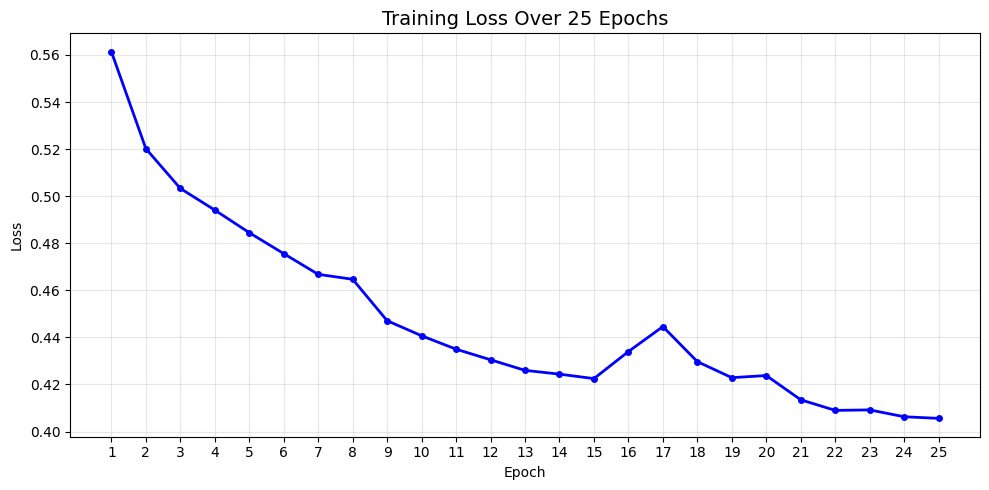

Saved!


In [1]:
import matplotlib.pyplot as plt

epochs = list(range(1, 26))
losses = [0.5614, 0.5202, 0.5033, 0.4941,
          0.4845, 0.4756, 0.4668, 0.4647,
          0.4471, 0.4407, 0.4350, 0.4305,
          0.4260, 0.4244, 0.4225, 0.4340,
          0.4446, 0.4297, 0.4229, 0.4238,
          0.4135, 0.4090, 0.4092, 0.4063,
          0.4056]

plt.figure(figsize=(10, 5))
plt.plot(epochs, losses,
         color='blue',
         linewidth=2,
         marker='o',
         markersize=4)
plt.title('Training Loss Over 25 Epochs',
          fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.xticks(epochs)
plt.tight_layout()
plt.savefig('loss_graph.png', dpi=150)
plt.show()
print("Saved!")

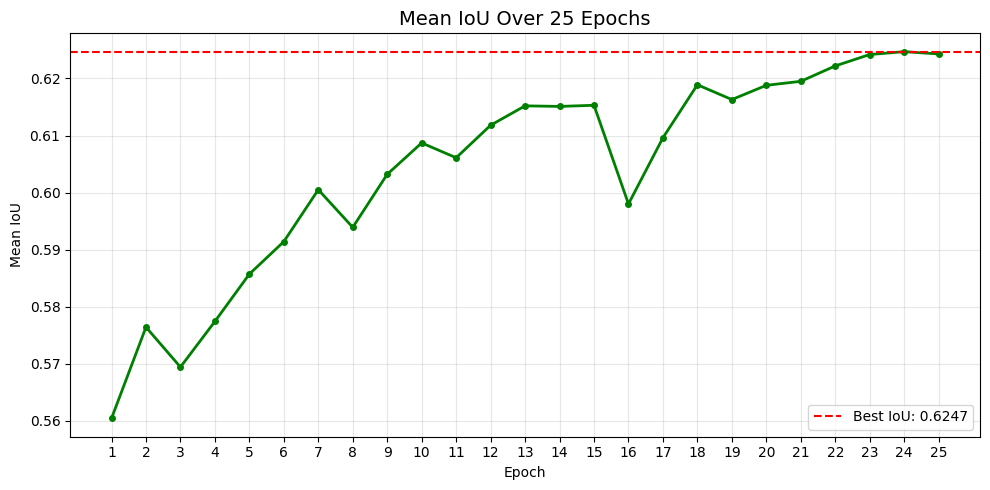

In [2]:
iou_scores = [0.5604, 0.5764, 0.5694,
              0.5774, 0.5857, 0.5914,
              0.6005, 0.5939, 0.6032,
              0.6087, 0.6061, 0.6118,
              0.6152, 0.6151, 0.6153,
              0.5980, 0.6096, 0.6189,
              0.6163, 0.6188, 0.6195,
              0.6222, 0.6242, 0.6247,
              0.6243]

plt.figure(figsize=(10, 5))
plt.plot(epochs, iou_scores,
         color='green',
         linewidth=2,
         marker='o',
         markersize=4)
plt.title('Mean IoU Over 25 Epochs',
          fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Mean IoU')
plt.grid(True, alpha=0.3)
plt.xticks(epochs)
plt.axhline(y=0.6247,
            color='red',
            linestyle='--',
            label=f'Best IoU: 0.6247')
plt.legend()
plt.tight_layout()
plt.savefig('iou_graph.png', dpi=150)
plt.show()

In [3]:
print("Training mask unique values:")
print([100, 200, 300, 500, 550, 800, 7100, 10000])
print("\nMissing classes:")
print("600 - Flowers ❌")
print("700 - Logs ❌")

Training mask unique values:
[100, 200, 300, 500, 550, 800, 7100, 10000]

Missing classes:
600 - Flowers ❌
700 - Logs ❌


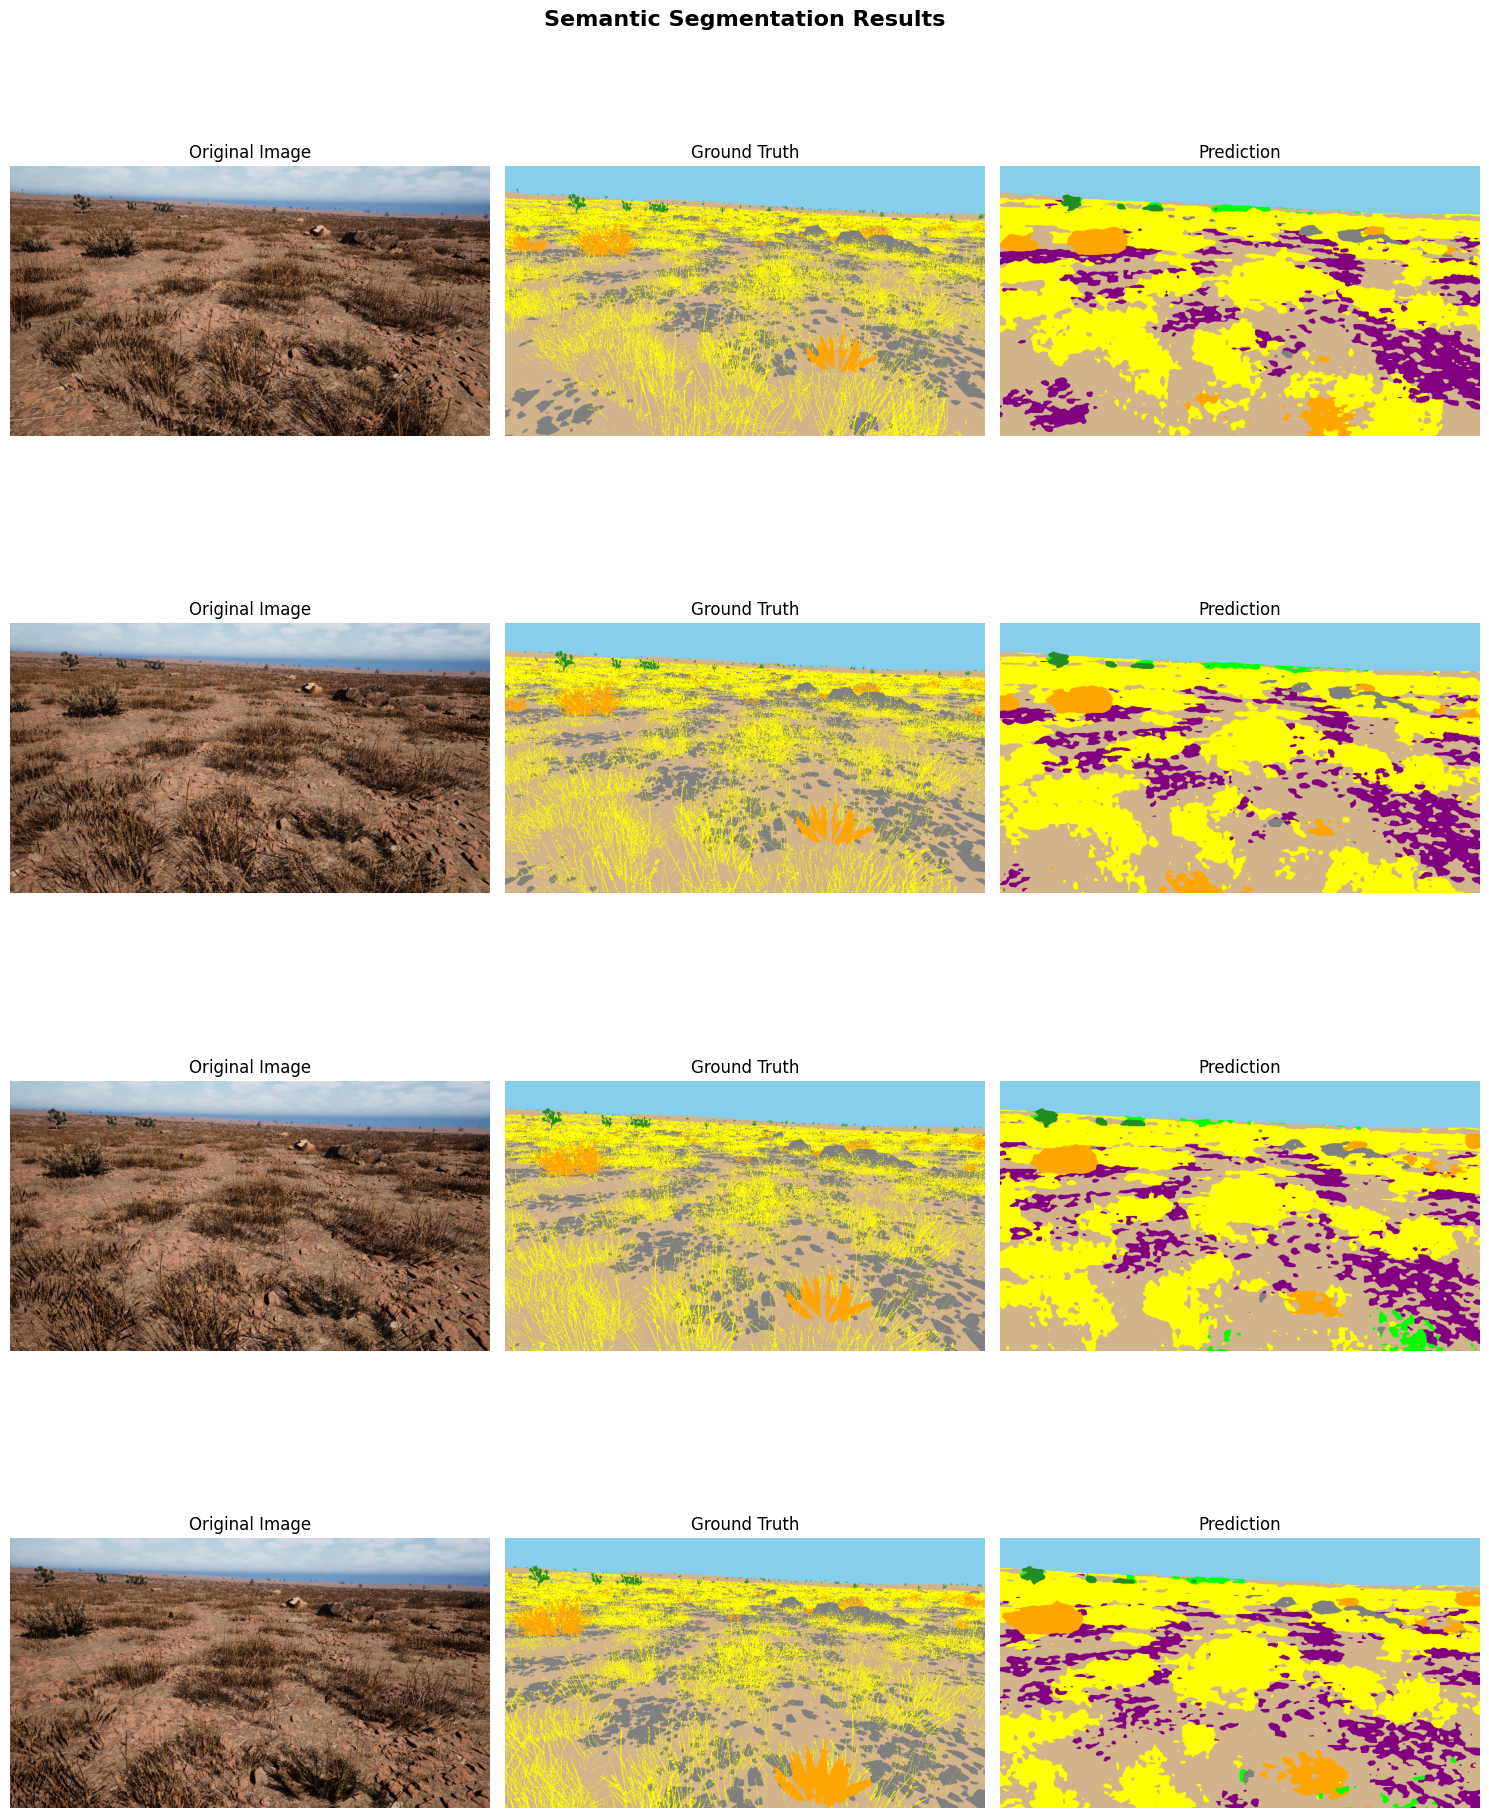

Saved to Drive! ✅


In [10]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch
import torch.nn.functional as F
import albumentations as A
from albumentations.pytorch import ToTensorV2
import os

# Color map for each class
COLOR_MAP = {
    0: (34, 139, 34),    # Trees → Forest Green
    1: (0, 255, 0),      # Lush Bushes → Bright Green
    2: (255, 255, 0),    # Dry Grass → Yellow
    3: (255, 165, 0),    # Dry Bushes → Orange
    4: (128, 0, 128),    # Ground Clutter → Purple
    5: (255, 20, 147),   # Flowers → Pink
    6: (139, 69, 19),    # Logs → Brown
    7: (128, 128, 128),  # Rocks → Gray
    8: (210, 180, 140),  # Landscape → Tan
    9: (135, 206, 235),  # Sky → Light Blue
}

def prediction_to_color(pred_mask):
    color_mask = np.zeros(
        (pred_mask.shape[0], pred_mask.shape[1], 3),
        dtype=np.uint8
    )
    for class_id, color in COLOR_MAP.items():
        color_mask[pred_mask == class_id] = color
    return color_mask

# Transform
img_transform = A.Compose([
    A.Resize(512, 512),
    A.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    ToTensorV2()
])

# Pick 4 sample test images
test_files = sorted(os.listdir(TEST_IMAGES))
samples = test_files[0:4]

fig, axes = plt.subplots(
    4, 3,
    figsize=(15, 20)
)

for idx, fname in enumerate(samples):
    # Load image
    img = np.array(Image.open(
        os.path.join(TEST_IMAGES, fname)
    ).convert('RGB'))

    # Load ground truth mask
    mask = np.array(Image.open(
        os.path.join(TEST_MASKS, fname)
    ))
    mask = convert_mask(mask)

    # Predict
    transformed = img_transform(image=img)
    img_tensor = transformed['image'].unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_tensor)
        pred = F.interpolate(
            output,
            size=(mask.shape[0], mask.shape[1]),
            mode='bilinear',
            align_corners=False
        ).argmax(dim=1).squeeze().cpu().numpy()

    # Convert to color
    pred_color = prediction_to_color(pred)
    mask_color = prediction_to_color(mask)

    # Plot
    axes[idx, 0].imshow(img)
    axes[idx, 0].set_title('Original Image')
    axes[idx, 0].axis('off')

    axes[idx, 1].imshow(mask_color)
    axes[idx, 1].set_title('Ground Truth')
    axes[idx, 1].axis('off')

    axes[idx, 2].imshow(pred_color)
    axes[idx, 2].set_title('Prediction')
    axes[idx, 2].axis('off')

plt.suptitle(
    'Semantic Segmentation Results',
    fontsize=16,
    fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    '/content/drive/MyDrive/hackathon/predictions.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()
print("Saved to Drive! ✅")

In [7]:
CLASS_MAP = {
    100: 0,    # Trees
    200: 1,    # Lush Bushes
    300: 2,    # Dry Grass
    500: 3,    # Dry Bushes
    550: 4,    # Ground Clutter
    600: 5,    # Flowers
    700: 6,    # Logs
    800: 7,    # Rocks
    7100: 8,   # Landscape
    10000: 9   # Sky
}

def convert_mask(mask_array):
    mask_array = mask_array.astype(np.int32)
    new_mask = np.zeros_like(mask_array, dtype=np.int64)
    for original_id, new_id in CLASS_MAP.items():
        new_mask[mask_array == original_id] = new_id
    return new_mask

print("convert_mask defined! ✅")

convert_mask defined! ✅


In [2]:
!pip install segmentation-models-pytorch


   ---------------------------------------- 0.0/2.6 MB ? eta -:--:--
   ------------------------ --------------- 1.6/2.6 MB 7.3 MB/s eta 0:00:01
   ---------------------------------------- 2.6/2.6 MB 6.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/4.3 MB ? eta -:--:--
   -------------- ------------------------- 1.6/4.3 MB 7.1 MB/s eta 0:00:01
   ----------------------------- ---------- 3.1/4.3 MB 7.1 MB/s eta 0:00:01
   ---------------------------------------- 4.3/4.3 MB 6.7 MB/s eta 0:00:00

   ---------------------------------------- 0/3 [torchvision]
   ---------------------------------------- 0/3 [torchvision]
   ---------------------------------------- 0/3 [torchvision]
   ---------------------------------------- 0/3 [torchvision]
   ---------------------------------------- 0/3 [torchvision]
   ---------------------------------------- 0/3 [torchvision]
   ---------------------------------------- 0/3 [torchvision]
   ---------------------------------------- 0/3

In [3]:
import torch
import segmentation_models_pytorch as smp

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

model = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights=None,
    in_channels=3,
    classes=10,
)
model = model.to(device)

model_to_save = model.half()

torch.save(
    model_to_save.state_dict(),
    'best_model_small.pth'
)
model.eval()
print("Model loaded! ✅")

Using: cpu
Model loaded! ✅
